In [44]:
from HRV_and_CPC_analysis_functions import ecg_hrv_cpc_routine, spectrum_plot_dt, cpc_and_signals_plot
import sys
sys.path.append('/home/wolfgang/repos/sleep_research_io')
from sleep_research_functions import load_sleep_data, write_to_hdf5_file, get_metadata, read_in_routine
import os
import numpy as np
import pandas as pd
%load_ext autoreload
%autoreload 2
import re

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [10]:
cpc_spectrograms_dir = '/media/mad3/Projects/ICU_SLEEP_STUDY/data/data_analysis/CPC_spectrograms'
cpc_plots_dir = '/media/mad3/Projects/ICU_SLEEP_STUDY/data/data_analysis/CPC_plots'
# ecg_r_peak_dir = '/media/mad3/Projects/ICU_SLEEP_STUDY/data/data_analysis/BMR_resampled_ECG_and_rpeaks'
vitals_hrv_dir = '/media/mad3/Projects/ICU_SLEEP_STUDY/Sleep_And_Breathing/icu_files_v2_hrv'

do_plots = True

In [42]:
files = os.listdir(vitals_hrv_dir)

In [43]:
files

['icusleep_169.h5',
 'icusleep_149.h5',
 'icusleep_178.h5',
 'icusleep_152.h5',
 'icusleep_100.h5',
 'icusleep_123.h5',
 'icusleep_051.h5',
 'icusleep_122.h5',
 'icusleep_047.h5',
 'icusleep_037.h5',
 'icusleep_050.h5',
 'icusleep_042.h5',
 'icusleep_061.h5',
 'icusleep_153.h5']

In [49]:
file

'icusleep_061.h5'

In [47]:
files[-2:]

['icusleep_061.h5', 'icusleep_153.h5']

/home/wolfgang/repos/ICU-Sleep/code1/HRV_and_CPC_analysis_functions.py:250: RuntimeWarning: divide by zero encountered in log10
  var = 20*np.log10(var)
/home/wolfgang/repos/ICU-Sleep/code1/HRV_and_CPC_analysis_functions.py:250: RuntimeWarning: divide by zero encountered in log10
  var = 20*np.log10(var)


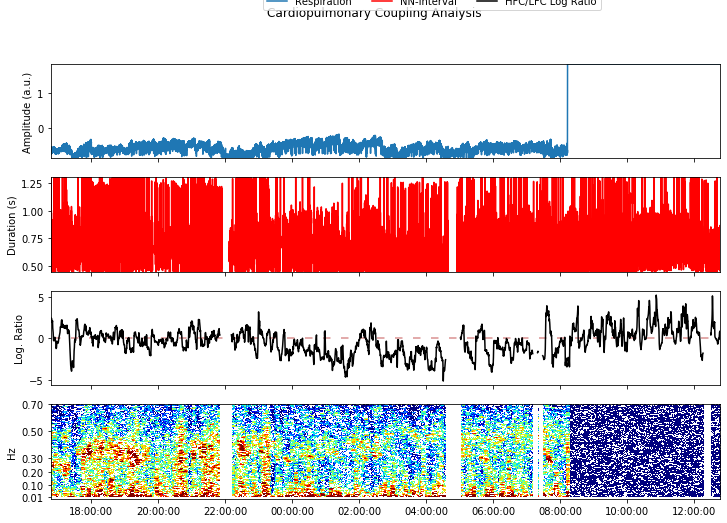

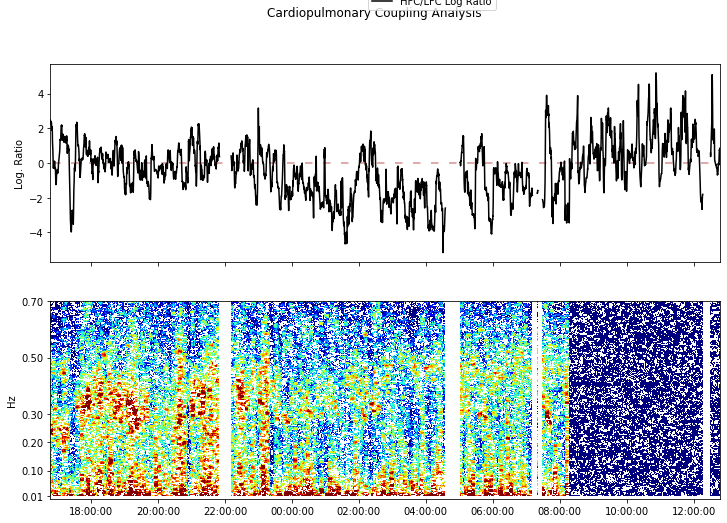

In [50]:
for file in files[-1:]:
    study_id = re.search('\d\d\d', file)[0]

    vitals_hrv_path = os.path.join(vitals_hrv_dir, f'icusleep_{str(study_id).zfill(3)}.h5')
    cpc_spectrogram_path = os.path.join(cpc_spectrograms_dir, 'CPC_spectrogram_' + str(study_id).zfill(3) + '.csv')
    data_vitals, hdr_vitals, fs_vitals = read_in_routine(vitals_hrv_path)

    cpc_df = pd.read_csv(cpc_spectrogram_path)
    cpc_df.rename({'Unnamed: 0': 'datetime'}, axis=1, inplace=True)
    cpc_df['datetime'] = pd.to_datetime(cpc_df['datetime'], infer_datetime_format=1)
    cpc_df.set_index('datetime', inplace=True)
    
    if do_plots & (cpc_df is not None):

        resp = data_vitals['movavg_0_5s']
        hfc_lfc_ratio = data_vitals[['cpc_hfc_lfc_ratio']]
        fig = cpc_and_signals_plot(cpc_df, hfc_lfc_ratio, resp, data_vitals['nn'])
        fig.savefig(os.path.join(cpc_plots_dir, f'signals_cpc_{str(study_id).zfill(3)}.jpg'), dpi=300)
        fig.savefig(os.path.join(cpc_plots_dir, f'signals_cpc_{str(study_id).zfill(3)}.pdf'), dpi=300)
        fig = cpc_and_signals_plot(cpc_df, hfc_lfc_ratio)
        fig.savefig(os.path.join(cpc_plots_dir, f'cpc_{str(study_id).zfill(3)}.jpg'), dpi=300)
        fig.savefig(os.path.join(cpc_plots_dir, f'cpc_{str(study_id).zfill(3)}.pdf'), dpi=300)
